# Лабораторная работа 3

## Сингулярное разложение и его приложения

Напомним, что сингулярным разложением (SVD, Singular value decomposition) матрицы $A$ размера $m\times n$ называется представление

$$A = U\Sigma V^T,$$

где $U$ — ортогональная матрица размера $m\times m$, $V$ — ортогональная матрица размера $n\times n$, $\Sigma = \mathrm{diag}(\sigma_1,\sigma_2,\sigma_3,\ldots)$ — диагональная матрица размера $m\times n$, в которой $\sigma_1\geqslant\sigma_2\geqslant\ldots\geqslant0$.

На самом деле требование, чтобы матрицы $U$ и $V$ были квадратными, избыточно. *Усечённым сингулярным разложением* мы будем называть разложение

$$A = U\Sigma V^T,$$

где $U$ и $V$ — матрицы с ортонормированными столбцами размеров $m\times k$ и $n \times k$ соответственно, $\Sigma$ — диагональная матрица размера $k\times k$, где $k = \min(m,n)$. Далее мы будем работать исключительно с усечённым разложением.

### Сжатие данных с помощью SVD = построение низкорангового приближения

Введём *норму Фробениуса* матрицы как

$$||A||_{frob} = \sqrt{\mathrm{tr}{A^TA}} = \sqrt{\sum\limits_{i,j}a^2_{i,j}}$$

Иными словами, это обычное евклидово расстояние на пространстве, которое получается, если все матрицы вытянуть в длинные векторы.

Зададимся вопросом: как найти матрицу $A_{r}$ ранга $r$, наименее отличающуюся от $A$ по норме Фробениуса (то есть для которой норма разности $||A - A_{r}||_{frob}$ минимальна). Оказывается, это можно сделать с помощью сингулярного разложения:

**Теорема.** Пусть $\Sigma_{r}$ — это матрица, полученная из $\Sigma$ заменой диагональных элементов $\sigma_{i}$ ($i > r$) нулями, тогда $A_{r} = U\Sigma_{r}V^T$.

Это можно переписать и в более экономичном виде. Если

$$A = \underbrace{
\begin{pmatrix}
u_{11} & \ldots & u_{1k}\\
\vdots & & \vdots\\
u_{m1} & \ldots & u_{mk}
\end{pmatrix}}_{=U}\cdot\underbrace{{
\begin{pmatrix}
\sigma_{1} & &\\
 & \sigma_{2} & \\
 & & \ddots
\end{pmatrix}}
}_{=\Sigma}\cdot \underbrace{
\begin{pmatrix}
v_{11} & \ldots & v_{n1}\\
\vdots & & \vdots\\
v_{1k} & \ldots & v_{nk}
\end{pmatrix}}_{=V^T}$$

то

$$A_{r} = \underbrace{
\begin{pmatrix}
u_{11} & \ldots & u_{1r}\\
\vdots & & \vdots\\
u_{m1} & \ldots & u_{mr}
\end{pmatrix}}_{=U_r}\cdot\underbrace{{
\begin{pmatrix}
\sigma_{1} & &\\
 & \ddots & \\
 & & \sigma_{r}
\end{pmatrix}}
}_{=\Sigma_r}\cdot \underbrace{
\begin{pmatrix}
v_{11} & \ldots & v_{n1}\\
\vdots & & \vdots\\
v_{1r} & \ldots & v_{nr}
\end{pmatrix}}_{=V^T_r}$$

При этом

$$||A - A_{r}||_{frob} = \sqrt{\sum\limits_{i\geqslant r+1} \sigma_{i}^2}$$

Если сингулярные значения матрицы падают достаточно быстро (а в реальных задачах часто бывает именно так), то норма разности будет малой при сравнительно небольшом значении $r$.

На хранение исходной матрицы нам требовалось $m\times n$ памяти. Теперь же, если мы будем хранить отдельно $U_r$, $V_r$ и диагональные элементы $\Sigma_r$, затраты памяти составят $mr + nr + r = r(m + n + 1)$.

**Разложение на компоненты ранга 1**

Обозначим через $u_1,\ldots, u_k$ столбцы матрицы $U$, а через $v_1, \ldots, v_k$ столбцы матрицы $V$. Тогда имеет место равенство

$$A = u_1\sigma_{1}v_1^T + u_2\sigma_{2}v_2^T + u_3\sigma_{3}v_3^T + \ldots$$

Матрицу $u_k\sigma_{k}v_k^T = \sigma_{k}u_kv_k^T$ мы будем называть $k$-й компонентой ранга 1 матрицы $A$. Отметим, что слагаемые в этой сумме ортогональны относительно скалярного произведения $(X, Y) = \mathrm{tr}(X^TY)$ (порождающего норму Фробениуса).

Как нетрудно заметить,

$$A_{r} = \sigma_{1}u_1v_1^T + \sigma_{2}u_2v_2^T + \ldots + \sigma_{r}u_rv_r^T$$

**Технические детали (SVD в Питоне)**

Есть несколько способов сделать в Питоне сингулярное разложение; мы пока предлагаем Вам использовать

`import scipy.linalg as sla`

`U, S, Vt = sla.svd(X, full_matrices=False)`

Для ознакомления с особенностями этой функции рекомендуем обратиться к [документации](https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.svd.html) (в частности, обратите внимание на то, какие именно объекты она возвращает).

### Правила оформления графиков

При работе с данными часто неудобно делать какие-то выводы, если смотреть на таблицу и числа в частности, поэтому важно уметь визуализировать данные. 

У matplotlib, конечно же, есть [документация](https://matplotlib.org/users/index.html) с большим количеством [примеров](https://matplotlib.org/examples/), но для начала достаточно знать про несколько основных типов графиков:
- plot — обычный поточечный график, которым можно изображать кривые или отдельные точки;
- hist — гистограмма, показывающая распределение некоторой величины;
- scatter — график, показывающий взаимосвязь двух величин;
- bar — столбцовый график, показывающий взаимосвязь количественной величины от категориальной.

Ещё одна билиотека для визуализации: [seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html). Это настройка над matplotlib, иногда удобнее и красивее делать визуализации через неё. 

Не забывайте про базовые принципы построения приличных графиков:
- оси должны быть подписаны, причём не слишком мелко;
- у графика должно быть название;
- если изображено несколько графиков, то необходима поясняющая легенда;
- для точек из разных выборок, необходимо использовать разные цвета;
- все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном);
- размер графика должен быть таким, чтобы по нему несложно было сделать необходимые выводы о данных;
- если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах).

Помните, что проверяющий имеет право снизить оценку за неопрятные графики.

### Оценивание

Обратите внимание, что в каждом разделе есть задания на написания кода и есть вопросы. Вопросы дополняют задачи и направлены на то, чтобы проинтерпретировать или обосновать происходящее. Код без интерпретации не имеет смысла, поэтому отвечать на вопросы обязательно — за отсутствие ответов мы будем снижать баллы за задачи. Если Вы ответите на вопросы, но не напишете корректный код к соответствующим оцениваемым задачам, то в подавляющем большинстве случаев баллы за такое выставлены не будут.

### Формат сдачи
Задания сдаются через систему Anytask. Инвайт можно найти на странице курса. Присылать необходимо ноутбук с выполненным заданием. Сам ноутбук называйте в формате homework-practice-03-linregr-Username.ipynb, где Username — Ваша фамилия.

### Задание 1. Сжатие данных с помощью SVD

Загрузите выложенную на странице курса фотографию.

In [7]:
import numpy as np
from skimage.io import imread

img = imread(r'./assets/chain_small.JPG')
img = img.mean(axis=2) # это матрица из интенсивностей серого цвета; её уже можно подвергать SVD

Нарисуйте картинку:

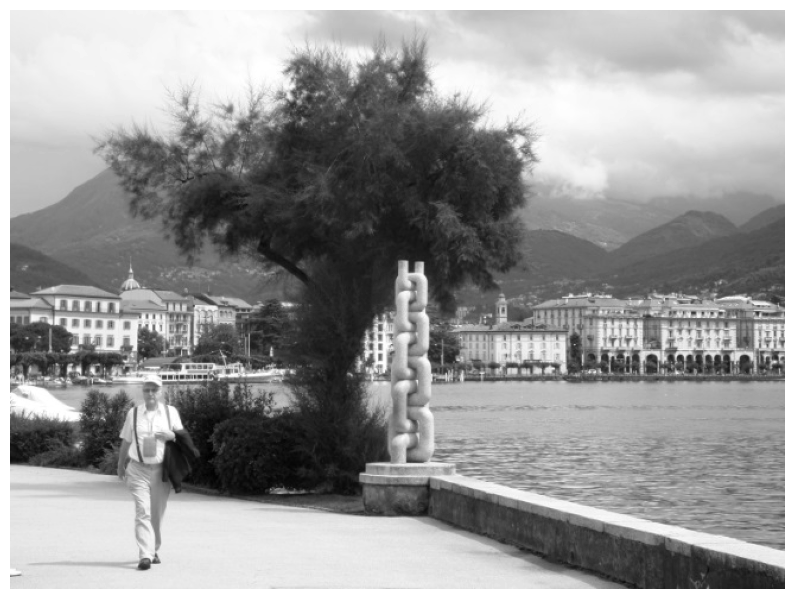

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(10, 10))
plt.axis('off')
imgplot = plt.imshow(img, cmap='gray')
plt.show()

Постройте сингулярное разложение этой матрицы.

In [468]:
from numpy.linalg import svd

U, S, VT = svd(img, full_matrices=False)

**1. [0.1 балла]** Нарисуйте график диагональных элементов матрицы $\Sigma$:

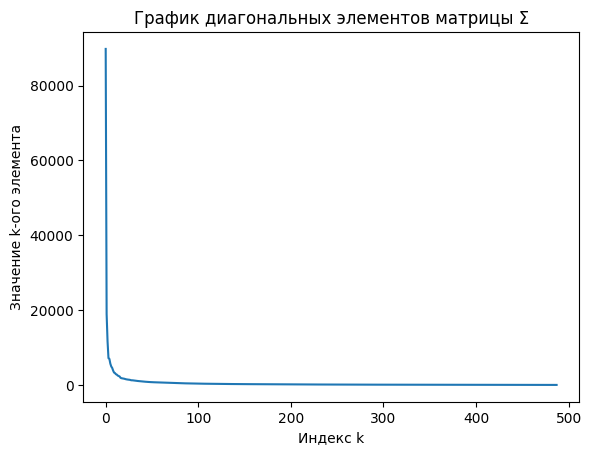

In [469]:
plt.plot(S)
plt.xlabel('Индекс k')
plt.ylabel('Значение k-ого элемента')
plt.title('График диагональных элементов матрицы Σ')
plt.show()

Кажется, что они убывают достаточно быстро и есть надежда, что первые несколько компонент дадут картинку, близкую к исходной.

**Важно:** при визуализации различных компонент в этом задании используйте только матричные операции. В частности, избегайте циклов, функций `map` и `reduce`, а также специальных функций, находящих суммы компонент.

**2. [0.1 балла]** Визуализуйте первую компоненту ранга 1. Ожидали ли Вы увидеть именно это? Поясните.

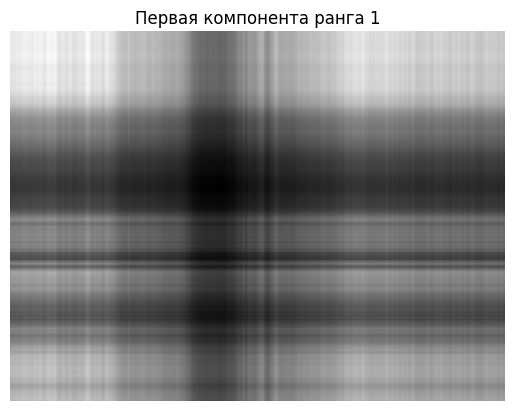

In [470]:
comp1 = S[0] * np.outer(U[:, 0], VT[0, :])

plt.imshow(comp1, cmap='gray')
plt.title('Первая компонента ранга 1')
plt.axis('off')
plt.show()

Ну раз у нас матрица примерно $500 \times 500$, то наверняка не стоило ожидать, что другая матричка ранга 1 будет напоминать нам ту картинку.

Тем не менее, она "повторяет" силуеты самого темного обьекта на картинке - дерева.

**3. [0.5 балла]** Визуализуйте суммы компонент ранга 1 с первой по двадцатую, с первой по пятидесятую, с двадцатой по сотую, с двадцатой по последнюю. Сделайте выводы.

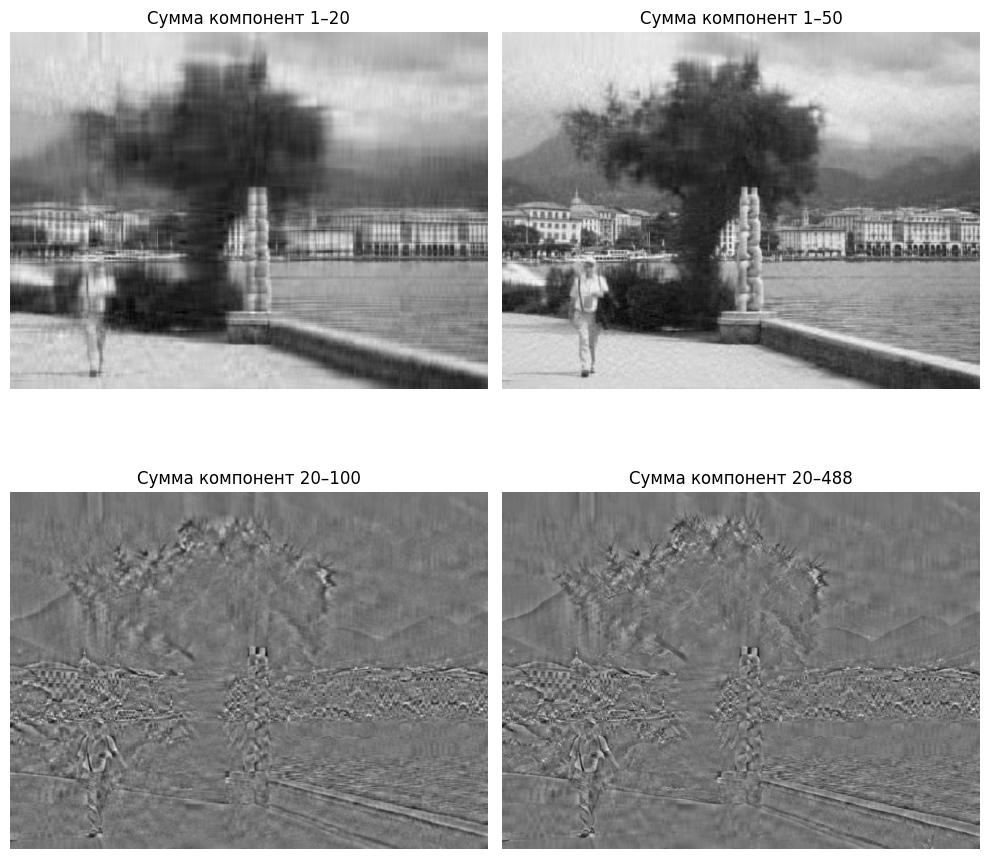

In [471]:
def rank_sum(i, j):
    i0, j0 = i-1, j
    return (U[:, i0:j0] * S[i0:j0]) @ VT[i0:j0, :]

ranges = [
    (1, 20,   '1–20'),
    (1, 50,   '1–50'),
    (20, 100, '20–100'),
    (20, len(S), f'20–{len(S)}')
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# пройдемся по подграфикам
for ax, (i, j, label) in zip(axes.ravel(), ranges):
    comp = rank_sum(i, j)
    ax.imshow(comp, cmap='gray')
    ax.set_title(f'Сумма компонент {label}')
    ax.axis('off')
plt.tight_layout()
plt.show()

1) 1-20 - так видит человек с -5(наверное), то есть теперь можно понять, что эта та изначальная картинка, вообщем все основные очертания видны, но очень далеко от приемливого по качеству, многие обьекты видно плохо, есть размытия и артефакты
2) картинка стала сильно лучше, но теперь есть эффект "мыла" и остались некоторые артефакты в виде разводов.
3) Видим очертания картинки, которые задают шумы и границы
4) Эти шумы стали четче, добавились детали

**4. [0.35 балла]** Как Вам кажется, какие компоненты нужно взять для достаточно хорошего восстановления исходного изображения? Аргументируйте свой ответ. Не забудьте визуализировать сумму выбранных компонент.

*Комментарий: для получения полного балла за это задания постарайтесь привести более убедительный аргумент, нежели Ваши субъективные впечатления от сравнения полученного изображения с исходным.*

Во первых, раз наибольшие значения $\sigma_i$ встречаются в начале, то они очевидно вносят наибольший "вклад" в картинку, поэтому точно нужно брать подряд идущие компоненты из начала списка.

Во вторых, из графика на $\sigma_i$ видно, что от 25 до последней компоненты значения примерно одинаковые, то есть после 25 потихоньку будут вносится небольшие изменения, а значит нужно лишь подобрать момент, когда исчезнут все "потертости", сильные размытия. При этом чуть уменьшенная четкость изображения не так страшна. 

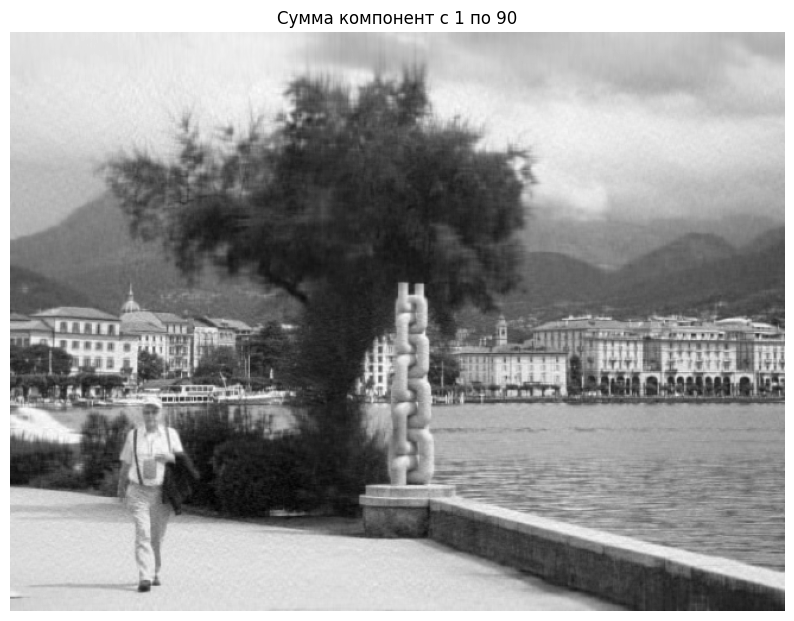

In [472]:
best_cnt_comp = 90
best_img = rank_sum(1, best_cnt_comp)

plt.figure(figsize=(10, 10))
plt.imshow(best_img, cmap='gray')
plt.title(f'Сумма компонент с 1 по {best_cnt_comp}')
plt.axis('off')
plt.show()

**Почему 90?**

Я искал момент с 75 компоненты до 100, когда над деревом пропадет размытие, да на само дерево станет можно хотя бы смотреть без потери сознания. Да и заодно человек стал сильно четче. Теперь выглядит как фотка которую перекинули в васап(ВАСААААППП), и она чуть порезало качество.

**5. [0.15 балла]** Во сколько раз меньше памяти (теоретически) потребуется для хранения нового изображения по сравнению с исходным?

На хранение исходной матрицы нам требовалось $m\times n$ памяти. Теперь же, если мы будем хранить отдельно $U_r$, $V_r$ и диагональные элементы $\Sigma_r$, затраты памяти составят $mr + nr + r = r(m + n + 1)$.

То есть получим соотношение:
$$
\frac{mn}{r(m + n + 1)}
$$

In [473]:
m, n = img.shape
ratio = (m*n) / (best_cnt_comp*(m + n + 1))
print(f'Новое изображение требует в {ratio:.2f} раз меньше памяти.')

Новое изображение требует в 3.10 раз меньше памяти.


**6. [0.25 балла]** Подсчитайте, сколько в действительности места в памяти компьютера занимают исходная матрица и компоненты её сингулярного разложения. Согласуется ли этот результат с ответом предыдущего пункта? Сделайте выводы.

In [474]:
old_bytes = img.nbytes

Ur = U[:, :best_cnt_comp]
Sr = S[:best_cnt_comp]
VTr = VT[:best_cnt_comp, :]

new_bytes = Ur.nbytes + Sr.nbytes + VTr.nbytes

print(f"Исходная матрица: {old_bytes/1024**2:.2f} МБ")
print(f"Усечённая SVD (r={best_cnt_comp}): {new_bytes/1024**2:.2f} МБ")
print(f"Во сколько раз меньше: {old_bytes/new_bytes:.2f}")


Исходная матрица: 2.43 МБ
Усечённая SVD (r=90): 0.78 МБ
Во сколько раз меньше: 3.10


Результат совпал с теоретическим, что и было ожидаемо

### Задание 2. Геометрия SVD. Визуализация данных с помощью SVD

**Геометрический смысл SVD**

Допустим, что у нас есть выборка $x_1,\ldots,x_m\in\mathbb{R}^n$. Запишем её в матрицу объекты-признаки

$$X = \begin{pmatrix}
x_{11} & \ldots & x_{1n}\\
\vdots & & \vdots\\
x_{m1} & \ldots & x_{mn}
\end{pmatrix}$$

(строки — объекты, столбцы — признаки) и сделаем SVD-разложение: $X = U\Sigma V^T$. Его можно интерпретировать следующим образом:

$$X = U\Sigma\cdot V^T,$$

где $U\Sigma$ — это матрица объекты-признаки для тех же объектов, но в новых признаках, полученных из исходных с помощью линейного преобразования $V$ (напоминаем, что умножение на матрицу справа соответствует преобразованию столбцов). Попробуем понять, чем замечательны эти признаки.

Рассмотрим матрицу $X^TX = V\Sigma^2V^T$. Легко видеть, что это матрица Грама системы столбцов матрицы $X$; иными словами, в ней записаны скалярные произведения векторов различных признаков. Из лекций вы знаете, что $\sigma_1^2$, квадрат первого сингулярного числа, это наибольшее собственное значение матрицы $X^TX$, а $v_1$, первый столбец матрицы $V$, — это соответствующий собственный вектор. Можно показать, что

$$\sigma_1 = \mathrm{max}_{w}\frac{|Xw|}{|w|} = \mathrm{max}_{|w| = 1}\left(|Xw|\right).$$

Попробуем осознать физический смысл этой штуки. Напомним, что строки матрицы $X$ — это координаты объектов $x_1,\ldots,x_m$ в пространстве признаков. Произведение $Xw$ — это вектор из значений на тех же самых объектах некоторого нового признака, являющегося линейной комбинацией исходных с коэффициентами $w_1,\ldots,w_n$:

$$Xw = w_1\begin{pmatrix} x_{11}\\ \ldots \\ x_{m1}
\end{pmatrix} + w_2\begin{pmatrix} x_{12}\\ \ldots \\ x_{m2}
\end{pmatrix} + \ldots + w_n\begin{pmatrix} x_{1n}\\ \ldots \\ x_{mn}
\end{pmatrix}$$

Соответственно, $|Xw|^2$ — это квадрат длины вектора, составленного из значений нового признака.

Таким образом, первому сингулярному значению $\sigma_1$ отвечает такой признак, у которого сумма квадратов значений максимальна, то есть признак, принимающий, условно говоря, самые большие значения.

Резюмируя, мы можем сказать, что сингулярное разложение делает следующее:
- находит новый признак (новое направление) вдоль которого "дисперсия"$^1$ максимальна;
- в ортогональной ему плоскости находит признак, вдоль которого "дисперсия" максимальна;
- и так далее.

---
$^1$ настоящая выборочная дисперсия с точностью до числового множителя была бы равна $|Xw - \overline{Xw}|^2$, где $\overline{Xw} = \frac1m\sum_{i=1}^m(Xw)_i$ — среднее значения признака.

**1. [1.25 балла]** Пусть $\sigma_1$ — старшее сингулярное число матрицы $X$ размера $m \times n$. Покажите, что верна цепочка равенств
$$\sigma_1 = \mathrm{max}_{w}\frac{|Xw|}{|w|} = \mathrm{max}_{|w| = 1}~|Xw| = \mathrm{max}_{|u|=|v| = 1}~|u^T Xv|.$$

**Подсказки:**
* при доказательстве равенства $\sigma_1 = \mathrm{max}_{w}\frac{|Xw|}{|w|}$ выразите вектор $w$ как $\alpha\cdot v$, где $|v|=1$, и рассмотрите описанное выражение
* при доказательстве равенства $\sigma_1 = \mathrm{max}_{|w| = 1}~|Xw|$ представьте $w$ в виде линейной комбинации ортонормированного базиса, состоящего из собственных векторов оператора $X^TX$, и внимательно посмотрите на произведение $wX^TXw$
* при доказательстве равенства $\sigma_1 = \mathrm{max}_{|u|=|v| = 1}~|u^T Xv|$ разложите матрицу $X$ в SVD-разложение, а векторы $u$ и $w$ представьте в виде линейной комбинации векторов, являющихся столбцами матриц $U$ и $V$.

Представим $w$ в ортонормированном базисе, тогда получим, что $w = \displaystyle\sum_{i = 1}^{n}\beta_iv_i$, где $v_i$ - $i$-ый столбец матрицы $V$. Если $|w| = 1$, то получим, что $|\beta| = 1.$ То есть $w = V\beta$.

$|z|^2 = z^Tz$, тогда пусть $z = Xw \Rightarrow |Xw|^2 = w^TX^TXw$ 

$$
|Xw|^2 = w^TX^TXw = w^T(V\Sigma^2V^T)w = (V\beta)^T(V \Sigma^2 V^T) (V \beta) = \beta^T V^T V \Sigma^2 V^T V \beta = \beta^T \Sigma^2 \beta = \\
= \displaystyle\sum_{i = 1}^{n}\beta_i^2\sigma_i^2 \leq \sigma_1^2 \sum_{i = 1}^{n} \beta_i^2
$$

Тогда если $|w| = 1$, то получим, что $|Xw| \leq \sigma_1$, при этом равенство достигается при $w = v_1$ - первый столбец матрицы $V$. Отсюда

$\sigma_1 = \displaystyle\max_{|w| = 1} |Xw|$.

---

Докажем, что $\displaystyle\max_{|w| = 1} |Xw| = \max_{w} \frac{|Xw|}{|w|}$, для этого заметим, что $w = \alpha v$, где $|v| = 1$, тогда:

$$
\displaystyle\max_{w} \frac{|Xw|}{|w|} = \max_{|v| = 1} \frac{|X\alpha v|}{|\alpha v|} = \max_{|v| = 1} |Xv|
$$

---

Докажем, что $\sigma_1 = \displaystyle\max_{|u| = |v| = 1} |u^T X v|$:

$$
u^T X v = u^T(U \Sigma V^T)v = (U^Tu)^T\Sigma(V^Tv)
$$

Положим $\alpha = U^Tu, \beta = V^Tv$, тогда $|\alpha|^2 = |U^Tu|^2 = u^TUU^Tu = u^Tu = |u|^2 = 1$, аналогично получим $|\beta| = |v| = 1$. Тогда по неравенсту Коши-Буняковского получим:

$$
|u^T X v| = |\alpha^T (\Sigma \beta)| \leq |\alpha| |\Sigma \beta| = |\Sigma \beta| = \sqrt{\displaystyle\sum_{i = 1}^{min(n, m)}\beta_i^2 \sigma_i^2} \leq \sqrt{\sigma_1^2 \sum_{i = 1}^{min(n, m)}\beta_i^2} = \sigma_1
$$

При этом равенство очевидно достигается при $u = u_1$ и $v = v_1$.

Получили то что надо.

**2. [0.75 балла]** Рассмотрим матрицу $A = (a_{ij})$ размера $n \times n$, такую что $a_{ij} = \sin i \cdot \cos j$, причём нумерация ведётся с нуля. Найдите $r = \text{rk}A$ (можете считать, что $n > 1$), а также разложение (Compact SVD) $A=U \Sigma V^T$, где $U$ и $V$ — матрицы с ортонормированными столбцами размера $n\times r$, а $\Sigma = \mathrm{diag}(\sigma_1,\ldots,\sigma_r)$ — диагональная матрица размера $r\times r$, в которой $\sigma_1\geqslant\ldots\geqslant\sigma_r > 0$. 

Пусть $a = (\sin 0, \dots \sin (n - 1))^T, b = (\cos 0, \dots, \cos (n - 1))$, тогда $A = ab^T$, причем нулем слогаемых очевидно не обойтись при $n > 1 \Rightarrow rk A = 1$ по тензорному рангу матрицы.

Тогда $A = u_1\sigma_{1}v_1^T$. 

Найдем $\sigma_{1}$ как квадрат единственного собственного значения матрицы $X^TX$.

$$
X^TX = (ab^T)^T(ab^T) = ba^Tab^T = a^Ta(bb^T) \\
det(X^TX - \lambda) = \frac{tr(a^Tabb^T)}{n} = \sum_{i = 0}^{n - 1}\sin^2 i \sum_{i = 0}^{n - 1}\cos^2 i \Rightarrow \\
\Rightarrow \sigma_1 = \sqrt{\sum_{i = 0}^{n - 1}\sin^2 i} \cdot \sqrt{\sum_{i = 0}^{n - 1}\cos^2 i}
$$

Тогда выбрав:
$$
u_1 = \frac{a}{\sqrt{\sum_{i = 0}^{n - 1}\sin^2 i}} \\
v_1 = \frac{b}{\sqrt{\sum_{i = 0}^{n - 1}\cos^2 i}}
$$

Заметим, что действительно $(u_1, u_1) = 1, (v_1, v_1) = 1$.

**3. [0.5 балла]** Рассмотрим полное сингулярное разложение $A = U \Sigma V^T$ для матрицы размера $m \times n$, такой что $\text{rk}A=r$. Определим также линейное отображение $\mathcal{A} \colon \mathbb{R}^n \to \mathbb{R}^m$, которое действует умножением на матрицу $A$. Покажите, что $\text{Im}\mathcal{A} = \langle u_1, \ldots, u_r \rangle$, а $\text{Ker}\mathcal{A} = \langle v_{r+1}, \ldots, v_n \rangle$.

Рассмотрим полное SVD

$$
A = U\Sigma V^T,
$$

где

- $U = [u_1, \dots, u_m]\in \R^{m \times m}$ и $V=[v_1, \dots, v_n] \in \R^{n \times n}$ — ортонормированные,
- $\Sigma=\text{diag}(\sigma_1,\dots,\sigma_r,0,\dots,0)\in\R^{m\times n}$ с $\sigma_1\ge\cdots\ge\sigma_r>0$ ($rk(A) = r$).

**Образ $Im A$**

Давайте запишем $A = (a_1 | a_2 | \dots | a_n)$, где $a_i$ - $i$-ый столбец $A$.

Мы знаем, что $Im A$ - это $\langle a_1, a_2, \dots, a_n \rangle$, тогда посмотрим чему равен $a_i$:

$$
a_i = \displaystyle\sum_{j = 1}^{m}u_j \sigma_j v_{ij} = \sum_{j = 1}^{r}u_j \sigma_j v_{ij}
$$

То есть каждый столбец $A$ это линейная комбинация первых $r$ столбцов $U$. Осталось сказать, что каждый $u_i \in Im A$, но это тоже не сложно. Рассмотрим $x = V(0, \dots, 0, \frac{1}{\sigma_i}, 0, \dots, 0)^T$, тогда $Ax = U\Sigma V^T V(0, \dots, \frac{1}{\sigma_i}, 0, \dots, 0)^T = U(0, \dots, 0, 1, 0, \dots, 0)^T = a_i$. Чем все и доказано.

---

**$Ker A$**

$Ker A =$ {$x \in \R^n : Ax = 0$} $\iff$ {$x \in R^n : U\Sigma V^Tx = 0$} $\iff$ {$x \in R^n : \Sigma V^Tx = 0$}, так как $U$ - невырождена, то есть ее столбцы/строки ЛНЗ.

Обозначим $y = V^Tx$, тогда после умножения 

$$
\Sigma y = 0
\Longleftrightarrow
\sigma_i y_i = 0 \forall i=1,\dots,r,
$$

а $y_{r+1},\dots,y_n$ могут быть любыми, потому что в строках $\Sigma$ они уже нулевые. Следовательно

$$
y \in \{\,0\}^r \times \R^{n-r} = \langle e_{r+1}, \dots, e_n \rangle.
$$

Переходя обратно к $x=Vy$, получаем

$$
ker A =\langle v_{r+1}, \dots, v_n \rangle
$$




**4. [0.75 балла]** Рассмотрим матрицу $A$ размера $m \times n$, такую что $m \geqslant n$ и столбцы $A$ линейно независимы. Найдите матрицу $\Sigma$ из полного сингулярного разложения для матрицы $P = A(A^T A)^{-1} A^T$.

Мы знаем, что $\Sigma$ в полном сингулярном разложении будет иметь те же ненулевые собственные значения на диагонали(точнее сказать арифметические корни из них), что и $P^TP$ или же $PP^T$, остальные будут нулями. Тогда наша задача найти собственные значения любой из этих матриц, отсюда можно будет достать $\Sigma$. 

$$P^TP = (A(A^T A)^{-1} A^T)^T A(A^T A)^{-1} A^T = A((A^T A)^T)^{-1} A^T A(A^T A)^{-1} A^T = \\ = A(A^TA)^{-1} A^T A(A^T A)^{-1} A^T = A (A^T A)^{-1} A^T = P$$

То есть нам нужно лишь найти ненулевые собственные значения матрицы $P$.

Пусть $v$ - собственный вектор, то есть $Pv = \lambda v$, тогда:

1) $P^2v = \lambda Pv = \lambda^2 v$
2) $P^2v = Pv = \lambda v$, так как $P^2 = P$(мы это увидили когда искали $P^TP$).

То есть $\lambda^2 = \lambda$, отсюда получим, что все в среди собственных значений будет какое-то кол-во едениц, остальные нули.

Мы знаем, что $tr(P)$ равен сумме собственных значений, тогда $tr(P) = tr(A(A^T A)^{-1} A^T) = tr(A^TA(A^T A)^{-1}) = tr(E_n) = n,$ то кратность $\lambda = 1$ равно $n$, а нулей $m - n$.

Таким образом, 
$$
\Sigma = 
\begin{pmatrix}
E_n & 0 \\
0   & 0_{\,m-n}
\end{pmatrix}.
$$

**Визуализация данных с помощью SVD**

Выше мы обсудили, что первые из "новых" признаков — это признаки, значения которых, скажем так, наиболее разнообразны. Зачастую (хотя и не всегда) именно они несут в себе наиболее важные черты датасета. И если взять два-три первых, то датасет можно нарисовать и посмотреть на него — и, возможно, обнаружить какую-то структуру.

С помощью функции `dsklearn.datasets.load_digits()` загрузите датасет рукописных цифр [MNIST](http://yann.lecun.com/exdb/mnist/). В нём есть несколько атрибутов; вам сейчас будут нужны `digits.data` (`np.array`, строки которого — это вытянутые в одну строку значения пикселей) и `digits.target` (в них записаны соответствующие цифры).

0


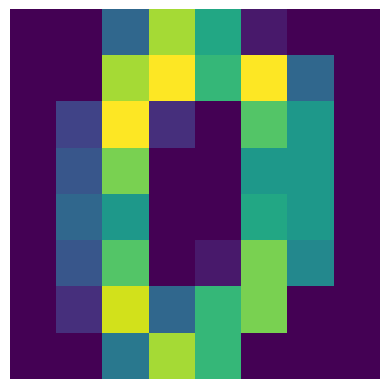

In [475]:
from sklearn import datasets

digits = datasets.load_digits()

print(digits.target[0])

plt.imshow(digits.data[0].reshape((8,8)))
plt.axis('off')
plt.show()

**5. [0.1 балла]** Примените к матрице `digits.data` сингулярное разложение.

In [476]:
imgs = digits.data

U, S, VT = svd(imgs, full_matrices=False)

**6. [0.65 балла]** Визуализируйте данные, спроецировав их на такую плоскость, чтобы координаты точек соответствовали первым двум новым признакам. Не забудьте покрасить точки, отвечающие различным цифрам, в разные цвета (если Вы любите красивые визуализации, разберитесь, как вместо точек рисовать маленькие цифры).

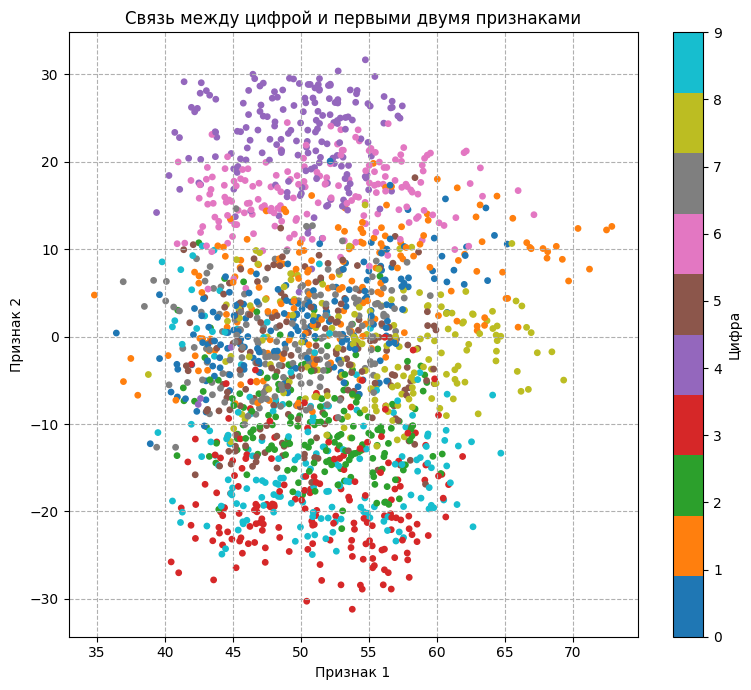

In [477]:
# новые признаки
scores = U * S

# print(scores.shape)

plt.figure(figsize=(8,7))
scatter = plt.scatter(scores[:,0], scores[:,1], c=digits.target, cmap='tab10', s=15, marker='o')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('Связь между цифрой и первыми двумя признаками')
plt.colorbar(scatter, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], label='Цифра')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

**7. [0.25 балла]** Теперь вычтите из каждого признака его среднее значение, снова сделайте SVD и нарисуйте разноцветные точки.

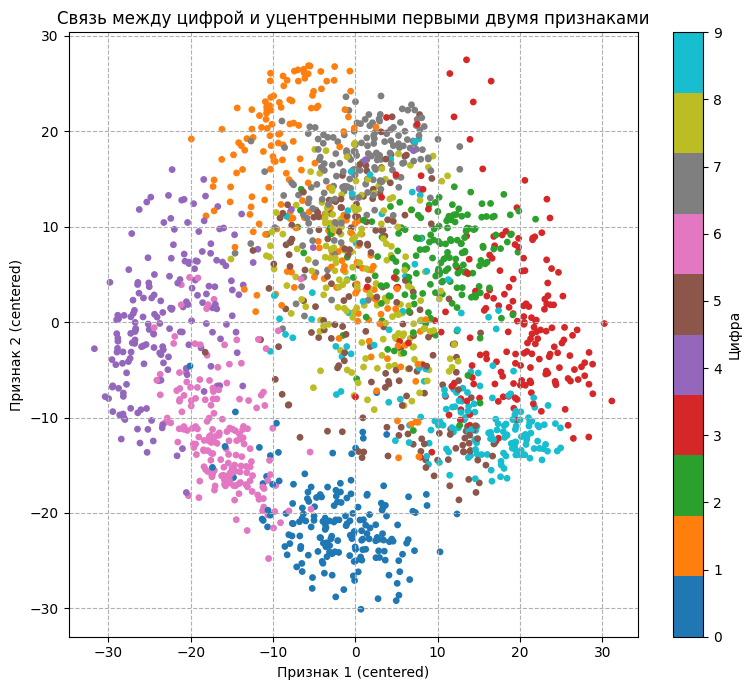

In [478]:
Xc = digits.data - digits.data.mean(axis=0)

# SVD на новом массиве
Uc, Sc, VTc = np.linalg.svd(Xc, full_matrices=False)
scores_c = Uc * Sc

plt.figure(figsize=(8,7))
scatter_c = plt.scatter(scores_c[:,0], scores_c[:,1], c=digits.target, cmap='tab10', s=15)
plt.xlabel('Признак 1 (centered)')
plt.ylabel('Признак 2 (centered)')
plt.title('Связь между цифрой и уцентренными первыми двумя признаками')
plt.colorbar(scatter_c, ticks=range(10), label='Цифра')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

**8. [0.25 балла]** Сравните выполненные Вами в двух предыдущих пунктах визуализации. Чем последняя выгодно отличается от первой?

На первой визуализации видим у каждой цифры примерно одно и то же значение первого признака (от 40 до 70), то есть первый признак на удивление не вносит значительной информации.

На второй же видим, что теперь цифры различаются не только по второму, но и по первому признаку, есть четкое разделение на группы(кластеры), ну может только "5" немного выбивается.

Отсюда можно сделать вывод, что второй способ сильно выгоднее, так как теперь отличать цифру по первым признакам стало сильно легче(до этого можно было отличить кое-как только по второму).

**9. [1 балл]** Сравните работу SVD с другим методом понижения размерности: [случайными гауссовскими проекциями](http://scikit-learn.org/stable/modules/generated/sklearn.random_projection.GaussianRandomProjection.html).

*Комментарий: Эксперименты без выводов, объясняющих полученные результаты, не оцениваются. Для получения полного балла за этот пункт постарайтесь провести как можно больше разноплановых экспериментов.*

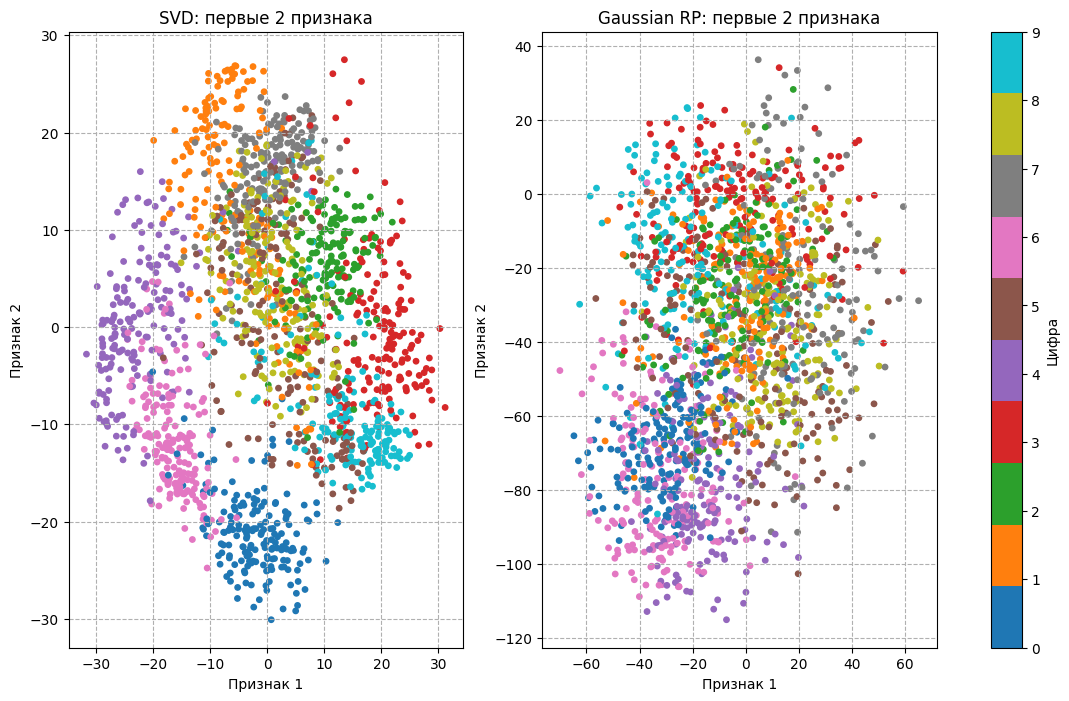

In [479]:
from sklearn.random_projection import GaussianRandomProjection

X = digits.data
y = digits.target

# 2D проекции
def plot_2d(X2, y, title, ax):
    scatter = ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap='tab10', s=15)
    ax.set_title(title)
    ax.set_xlabel('Признак 1')
    ax.set_ylabel('Признак 2')
    ax.grid(True, linestyle='--')
    return scatter

# Получим гаусовские проекции
grp2 = GaussianRandomProjection(n_components=2, random_state=13)
scores_grp2 = grp2.fit_transform(X)

# Сравним SVD vs GRP в 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
plot_2d(scores_c[:, :2], y, 'SVD: первые 2 признака', axes[0])
plot_2d(scores_grp2, y, 'Gaussian RP: первые 2 признака', axes[1])
fig.colorbar(axes[0].collections[0], ax=axes, ticks=range(10), label='Цифра')
plt.show()


#### Пробуем улучшить GRP

Вообще результат напоминает svd, но когда мы не делали усреднения.

Как видим в GRP можно разделить некоторые цифры, но где то получается абсолютная каша, в svd тоже такой эфект есть, но он значительно меньше: поэтому можно сделать вывод - пока **SVD с усреднением сильно лучше**

Небольшой фан. факт: пришлось наверное раз 10 пробовать разные сиды, чтобы получился наконец более менее приемлимый. Такой проблемы у svd нет.

Давайте попробуем тот же метод, как улучшали svd, а именно из каждого признака отнимем среднее.

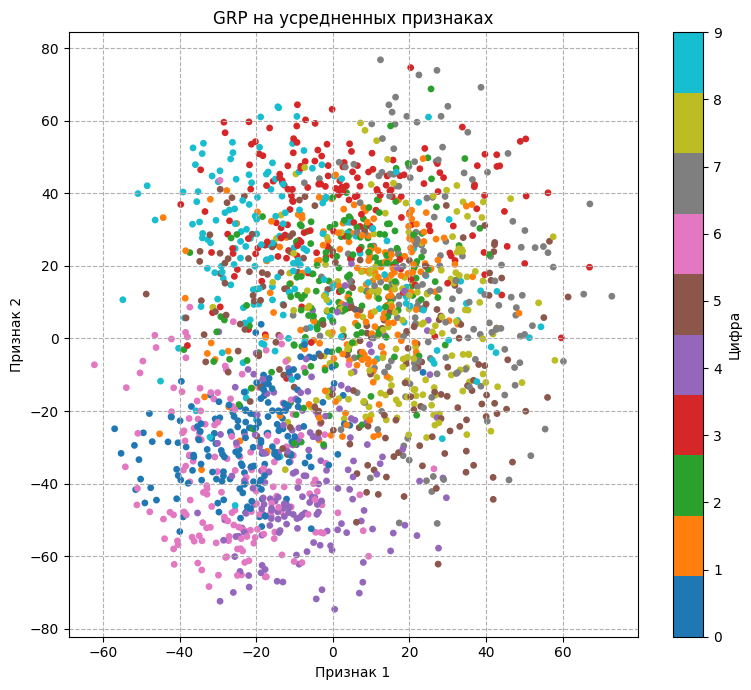

In [480]:
Xc = digits.data - digits.data.mean(axis=0)

# Получим гаусовские проекции на усредненных признаках
grp2 = GaussianRandomProjection(n_components=2, random_state=13)
scores_grp2 = grp2.fit_transform(Xc)

plt.figure(figsize=(8,7))
scatter = plt.scatter(scores_grp2[:,0], scores_grp2[:,1], c=digits.target, cmap='tab10', s=15, marker='o')
plt.xlabel('Признак 1')
plt.ylabel('Признак 2')
plt.title('GRP на усредненных признаках')
plt.colorbar(scatter, ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], label='Цифра')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

Заметим, что это никак не помогло, расстояние между точками осталось примерно таким же.

#### И на этом все?

Шутка конечно.

Давайте попробуем увеличить количество признаков, и посмотрим что получится. Вообще интересно посмотреть насколько станет лучше SVD по сравнению с 2D, а также сравнить насколько станет лучше GRP. 
Но встает вопрос, а как вообще это можно сделать, как понять насколько хорошо работает тот или иной метод(нас волнует визуализация)?

Какой вопрос, такой ответ, поэтому давайте не заморачиваться и просто нарисуем все в 3D точно также как было с 2D случаем, то есть координаты точки - это ее первые 3 значения признака. Для этого использовал [это](https://jakevdp.github.io/PythonDataScienceHandbook/04.12-three-dimensional-plotting.html):

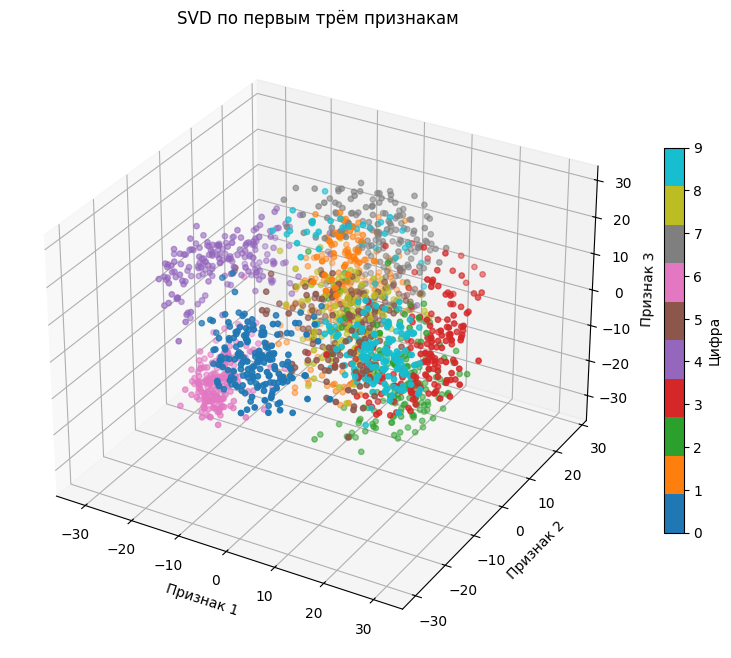

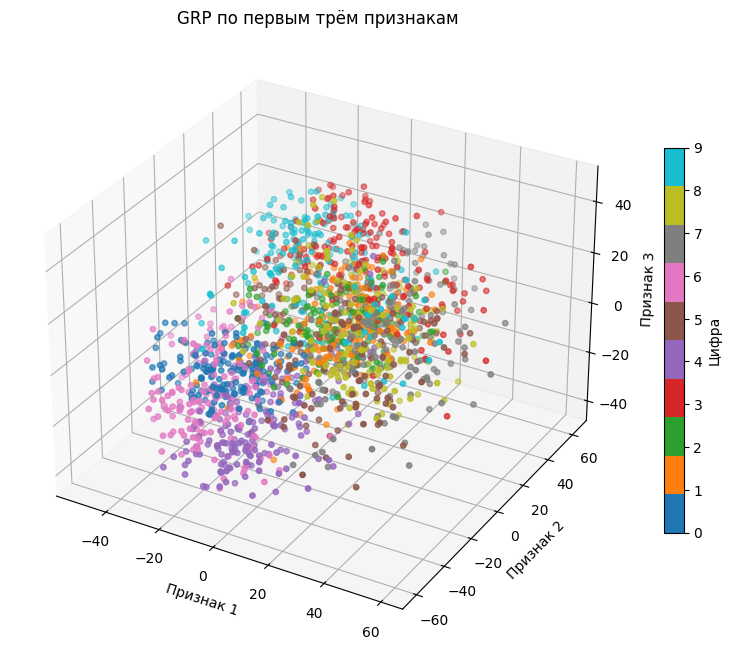

In [481]:
from mpl_toolkits import mplot3d

# возьмём первые три признака
x3, y3, z3 = scores_c[:,0], scores_c[:,1], scores_c[:,2]

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')
sc = ax.scatter(x3, y3, z3, c=y, cmap='tab10', s=15)
ax.set_xlabel('Признак 1')
ax.set_ylabel('Признак 2')
ax.set_zlabel('Признак 3')
ax.set_title('SVD по первым трём признакам')
fig.colorbar(sc, ticks=range(10), label='Цифра', shrink=0.5)
plt.tight_layout()
plt.show()

# Получим гаусовские проекции
grp3 = GaussianRandomProjection(n_components=3, random_state=13)
scores_grp3 = grp3.fit_transform(Xc)

# точно также возьмем первые 3
x3, y3, z3 = scores_grp3[:,0], scores_grp3[:,1], scores_grp3[:,2]

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection='3d')
sc = ax.scatter(x3, y3, z3, c=y, cmap='tab10', s=15)
ax.set_xlabel('Признак 1')
ax.set_ylabel('Признак 2')
ax.set_zlabel('Признак 3')
ax.set_title('GRP по первым трём признакам')
fig.colorbar(sc, ticks=range(10), label='Цифра', shrink=0.5)
plt.tight_layout()
plt.show()

Честно, пока сложно сказать что-то по графикам, очень уж хочется их покрутить

К сожалению способы из интернета сюда не подошли, пришлось обращатся к коварному gpt c следующим запросом:

- `Блок кода с графиком`
- А можешь сделать так чтобы график крутился?

Он предложил 2 варианта, второй из них как раз подошел(не без багов).

**Внимание**

Код может исполнятся **очень долго**(примерно 2-3 минуты), но очень рекомендую, это того стоит

А еще можно открыть файлы
1) [Анимация 1](./assets/digits_3d_rotate_svd.gif)
2) [Анимация 2](./assets/digits_3d_rotate_grp.gif)

In [ ]:
from matplotlib import animation
from IPython.display import Image

x3, y3, z3 = scores_c[:,0], scores_c[:,1], scores_c[:,2]

fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection='3d')
sc = ax.scatter(x3, y3, z3, c=y, cmap='tab10', s=15)
ax.set_xlabel('Признак 1')
ax.set_ylabel('Признак 2')
ax.set_zlabel('Признак 3')
ax.set_title('SVD: Крутящиеся 3D проекция')

def init():
    ax.view_init(elev=30, azim=0)
    return sc,

def animate(frame):
    ax.view_init(elev=30, azim=frame)
    return sc,

ani = animation.FuncAnimation(
    fig, animate, init_func=init,
    frames=360, interval=100, blit=True
)
plt.close(fig)

ani.save('digits_3d_rotate_svd.gif', writer='imagemagick', fps=20)
Image('digits_3d_rotate_svd.gif')

In [ ]:
x3, y3, z3 = scores_grp3[:,0], scores_grp3[:,1], scores_grp3[:,2]

fig = plt.figure(figsize=(6,6))
ax = plt.axes(projection='3d')
sc = ax.scatter(x3, y3, z3, c=y, cmap='tab10', s=15)
ax.set_xlabel('Признак 1')
ax.set_ylabel('Признак 2')
ax.set_zlabel('Признак 3')
ax.set_title('GRP: Крутящиеся 3D проекция')

def init():
    ax.view_init(elev=30, azim=0)
    return sc,

def animate(frame):
    ax.view_init(elev=30, azim=frame)
    return sc,

ani = animation.FuncAnimation(
    fig, animate, init_func=init,
    frames=360, interval=100, blit=True
)
plt.close(fig)

ani.save('digits_3d_rotate_grp.gif', writer='imagemagick', fps=20)
Image('digits_3d_rotate_grp.gif')

Вообще, теперь результаты 3D-GRP стали похожи на 2D-SVD когда мы использовали усреднения, точки одной цифры находятся достаточно кучно и некоторые цифры стало легко различить, но есть и проблемные пересечения.

Ну а 3D-SVD мягко говоря - это очень круто, но при этом все также осталась проблема с "5", хоть и менее выраженная.

То есть GRP работает, помогает снизить размерность, однако у него есть свои минусы:
- Результат не такой выраженный как у SVD
- Есть элемент случайности, бывают как очень хорошие проекции, так и очень плохие

### Задание 3. Когда SVD не сработает

**Disclaimer**

Цель этого задания — познакомить Вас не только с геометрическим смыслом сингулярного разложения, но и перекинуть очередной мостик между линейной алгеброй и анализом данных. К сожалению, на том берегу Вас встретят разные пока неизведанные понятия; мы постараемся по возможности дать какие-то определения, но, конечно, нет никакой возможности изложить на этих страницах полный курс теории вероятностей. Поэтому какие-то вещи останутся недосказанными или необоснованными; если Вам будет интересно, не стесняйтесь читать соответствующую литературу или хотя бы Википедию, а если нет, то мы надеемся, что хотя бы наглядное представление у Вас сформируется. В любом случае, нам хотелось бы, чтобы воспоминания об этом всколыхнулись в ваших головах, когда Вы будете это всё изучать в курсе по теории вероятностей.

Но начнём мы с того, что обсудим ситуацию, в которой SVD работает лучше всего: а именно, со случая, когда данные распределены нормально.

**Что такое плотность вероятности**

В дальнейшем Вам достаточно часто придётся сталкиваться со *случайными величинами*. Мы не будем сейчас пытаться строго определить, что это такое (для этого у вас будет целый курс по теории вероятностей), а остановимся только на одном его аспекте.

Если случайная величина $X$ принимает лишь конечное (или счётное) число значений $x_1,x_2,\ldots$, то чтобы задать её, достаточно описать, с какой вероятностью $X$ равна $x_i$: 

$$p_i = P(X = x_i)$$

таким образом, чтобы $\sum_ip_i = 1$. Если же $X$ принимает значения на каком-либо отрезке или на всей числовой прямой, то так уже не получится: в этом случае вероятность того, что $X$ равна какому-то конкретному $x_0$, обычно равна нулю. Как правило, заменой вероятностей $p_i$ служит *функция плотности распределения* $p(x)$. Смысл её таков:

$$P(\alpha\leqslant X\leqslant\beta) = \int\limits_{\alpha}^{\beta}p(x)dx$$

(в левой части стоит вероятность того, что значение $X$ лежит на отрезке $[\alpha,\beta]$).

Таким образом, функция $p(x)$ действительно играет роль "плотности": вероятность попасть в отрезок одной и той же длины тем выше, чем больше значения $p(x)$ на нём.

**Нормальное распределение**

Одним из самых важных примеров непрерывных распределений является *нормальное распределение*. Его плотность имеет вид

$$p(x) = \frac1{\sqrt{2\pi\sigma^2}}e^{-\frac{(x - a)^2}{2\sigma^2}}$$

У него есть два параметра:

- $a$ - *математическое ожидание*, имеющее смысл среднего значения и для нормального распределения совпадающее с центром симметрии распределения;
- $\sigma^2$ - *дисперсия*: чем она меньше, тем в большей степени распределение сконцентрировано подле своего математического ожидания

Нормальное распределение с параметрами $a$ и $\sigma^2$ можно кратко обозначать $\mathcal{N}(a, \sigma^2)$.

Чтобы проиллюстрировать это, мы сгененерируем много точек из распределений $\mathcal{N}(2, 0.25)$, $\mathcal{N}(0, 1)$ и $\mathcal{N}(0, 4)$ и по ним в каждом из этих случаев построим аппроксимацию функции плотности распределения. Обратите внимание, что параметр $a$ в `numpy` называется `loc`, $\sigma$ (без квадрата!) — `scale`

In [484]:
import numpy as np
from scipy.interpolate import UnivariateSpline
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns

/var/folders/l4/2y8c0j1d7c7g1xtmkvv06f4c0000gn/T/ipykernel_77901/2042633187.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(s, hist=False, kde=True,
/var/folders/l4/2y8c0j1d7c7g1xtmkvv06f4c0000gn/T/ipykernel_77901/2042633187.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distpl

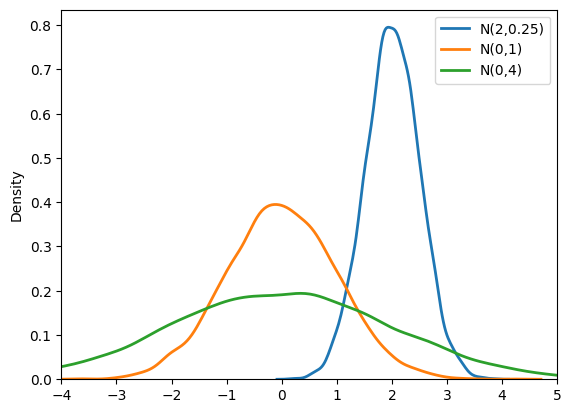

In [485]:
N = 10000
plt.xlim([-4,5])
s = np.random.normal(loc=2, scale=0.5, size=N)   # generate your data sample with N elements
sns.distplot(s, hist=False, kde=True, 
             bins=50,
             kde_kws={'linewidth': 2}, label='N(2,0.25)')

s = np.random.normal(loc=0, scale=1, size=N)   # generate your data sample with N elements
sns.distplot(s, hist=False, kde=True, 
             bins=50,
             kde_kws={'linewidth': 2}, label='N(0,1)')

s = np.random.normal(loc=0, scale=2, size=N)   # generate your data sample with N elements
sns.distplot(s, hist=False, kde=True, 
             bins=50,# color = 'darkblue',
             kde_kws={'linewidth': 2}, label='N(0,4)')

plt.legend()
plt.show()

**Функция плотности распределения в многомерном случае**

Если значения случайной величины $X$ — это многомерные векторы, функция плотности сохраняет примерно тот же смысл: если $\Omega\subseteq\mathbb{R}^n$, то

$$P(X\in\Omega) = \int\limits_{\Omega}p(x)dx$$

**Многомерное нормальное распределение**

Многомерное нормальное распределение определяется также двумя параметрами: *вектором средних* $a$ и положительно определённой *ковариационной матрицей* $\Sigma$; оно имеет плотность

$$p(x) = \frac1{(2\pi)^{n/2}|\Sigma|^{1/2}}e^{-\frac12(x - a)^T\Sigma^{-1}(x - a)}$$

где, напомним, $x$ — вектор из $\mathbb{R}^n$. Компоненты вектора $a$ — это математические ожидания отдельных координат $X$, а на диагонали матрицы $\Sigma$ стоят их *дисперсии* (настоящие, без кавычек). Вне диагонали стоят *ковариации* компонент $X$ (пока вам достаточно понимать, что если они равны нулю, то эти компоненты независимы$^1$).

---
$^1$ Точнее сказать, некоррелированны, однако для компонент многомерного нормального распределения независимость и некоррелированность равносильны (на самом деле редкое и удачное свойство!).

**Несколько фактов**

* Под (n-1)-мерным эллипсоидом будем понимать гиперповерхность в $\mathbb{R}^n$, такую что в некоторой прямоугольной декартовой системе координат её уравнение принимает вид $\sum_{i=1}^n \frac{x_i^2}{r_i^2} = 1$. Поверхности уровня $p(x) = c$ — это эллипсоиды.

*  Пользуясь теоремой о приведении квадратичной формы к главным осям, можно показать, что функция плотности многомерного нормального распределения представляется в виде произведения одномерных нормальных плотностей при переходе в новую систему координат. 
$$p(x)=\frac1{(2\pi)^{n/2}|\Sigma|^{1/2}}e^{-\frac12(x - a)^T\Sigma^{-1}(x - a)}\:\underset{\text{новая система координат}}{\to}\: p(x)=p(x_1)\cdot ...\cdot p(x_n)$$

    В частности, это означает, что с помощью замены координат можно добиться того, чтобы отдельные компоненты были независимы (то есть матрица ковариации $\Sigma$ диагональна).

А мы тем временем продемонстрируем это на конкретном примере, сгенерировав много точек из двумерного нормального распределения с вектором средних $(-1,3)$ и ковариационной матрицей

$$\begin{pmatrix}
1 & \frac32\\
\frac32 & 5
\end{pmatrix}$$

и нарисовав приближённо линии уровня функции плотности.

/var/folders/l4/2y8c0j1d7c7g1xtmkvv06f4c0000gn/T/ipykernel_77901/3039765410.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=s[:,0], y=s[:,1], shade=False, color='g')


<Axes: >

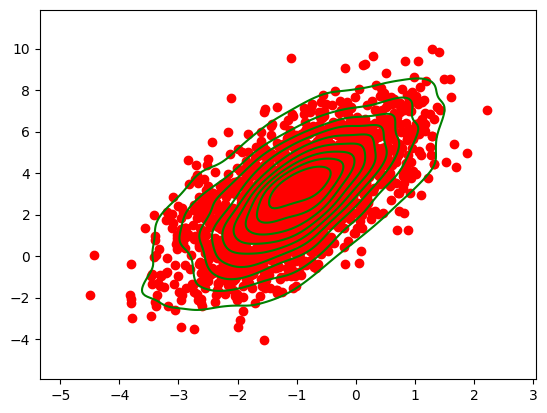

In [486]:
import seaborn as sns
import numpy as np

N = 2000
s = np.random.multivariate_normal(mean=np.array([-1,3]), cov=np.array([[1,1.5],[1.5,5]]), size=N)
plt.scatter(s[:,0], s[:,1], color='red')
sns.kdeplot(x=s[:,0], y=s[:,1], shade=False, color='g')

Как видите, линии уровня весьма напоминают эллипсы (только напоминают, потому что точек у нас всё-таки конечное число).

**1. [0 баллов]** Сгенерируйте выборку из 1000 точек $x_1,\ldots,x_{1000}$ из нормального распределения с вектором средних $a = (0,0)$ и ковариационной матрицей

$$\Sigma = \begin{pmatrix}
1 & -2\\
-2 & 5
\end{pmatrix}.$$

In [487]:
N = 1000
s = np.random.multivariate_normal(mean=np.array([0,0]), cov=np.array([[1,-2],[-2,5]]), size=N)

Очень уж хочется на нее посмотреть, так что давайте повторим график как выше.

/var/folders/l4/2y8c0j1d7c7g1xtmkvv06f4c0000gn/T/ipykernel_77901/36964278.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=s[:,0], y=s[:,1], shade=False, color='g')


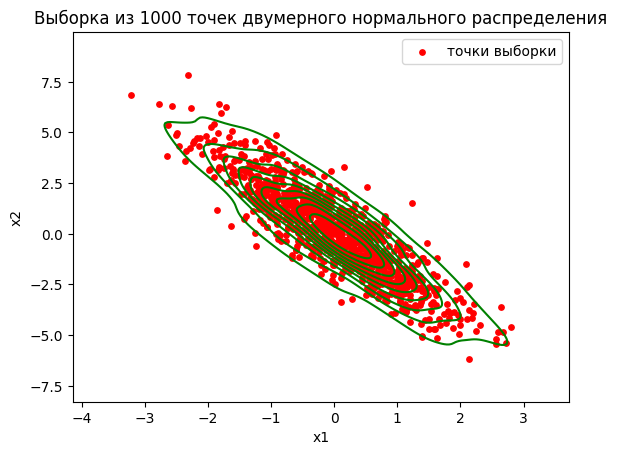

In [488]:
plt.title('Выборка из 1000 точек двумерного нормального распределения')
plt.xlabel('x1')
plt.ylabel('x2')

plt.scatter(s[:,0], s[:,1], color='red', s=15, label='точки выборки')
sns.kdeplot(x=s[:,0], y=s[:,1], shade=False, color='g')
plt.legend()

plt.show()

**2. [0.25 балла]** Сделайте SVD-разложение $X = U\Sigma V^T$. Нарисуйте на плоскости все точки $x_i$ и направления новых признаков. Убедитесь, что направления новых признаков примерно совпадают с направлениями полуосей эллипса, образованного точками.

/var/folders/l4/2y8c0j1d7c7g1xtmkvv06f4c0000gn/T/ipykernel_77901/3146852920.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X[:,0], y=X[:,1], shade=False, color='g', alpha=0.7)


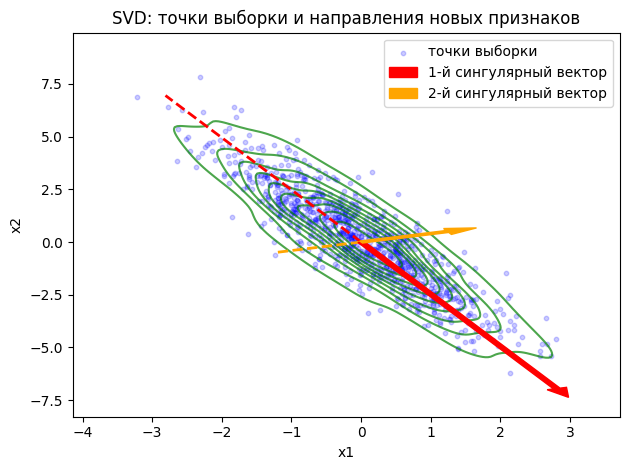

In [489]:
def do_svd_and_draw_dots_with_directions(X):
    U, S, VT = np.linalg.svd(X, full_matrices = False)

    # направления новых признаков — это строки матрицы Vt, 
    # в нашем случае первая и вторая строка
    v1 = VT[0]
    v2 = VT[1]

    # масштабируем стрелки соответствующим им значениям сингулярных чисел
    # (но поделим на константу а то без них они улетают)
    arrow1 = v1 * S[0] / 10
    arrow2 = v2 * S[1] / 10

    sns.kdeplot(x=X[:,0], y=X[:,1], shade=False, color='g', alpha=0.7)
    plt.scatter(X[:,0], X[:,1], color='b', s=10, label='точки выборки', alpha=0.2)

    # стрелки для векторов
    plt.arrow(0, 0, arrow1[0], arrow1[1], color='red', width=0.1, head_width=0.3,
            label='1-й сингулярный вектор', linestyle='-', zorder=5)
    plt.arrow(0, 0, arrow2[0], arrow2[1], color='orange', width=0.1, head_width=0.3,
            label='2-й сингулярный вектор', linestyle='-', zorder=5)

    # и в обратную сторону
    plt.plot([0, -arrow1[0]],
         [0, -arrow1[1]],
         color='red', linestyle='--', linewidth=2)
    plt.plot([0, -arrow2[0]],
         [0, -arrow2[1]],
         color='orange', linestyle='--', linewidth=2)

    plt.title('SVD: точки выборки и направления новых признаков')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.legend()
    plt.tight_layout()
    plt.show()

do_svd_and_draw_dots_with_directions(s)

**3. [0.5 балла]** Приведите к главным осям матрицу ковариации (это нужно сделать без привлечения `Python`) и убедитесь, что направления этих осей тоже примерно совпадают с наблюдаемыми направлениями полуосей эллипсоида.

P.S. мы не проходили что значит привести матрицу к главным осям(Либо я плохо слушал). Но в интернете написано, что просто нужно диагонализовать $\Sigma$, более формально:

$$
\Sigma = V D V^{-1}
$$

Где $D$ - диагональна, а $V$ - матрица перехода, состоящая из собственных векторов.

Найдем хар. многочлен:

$$
\chi_{\Sigma}(\lambda) = det(\Sigma - \lambda E) = det(
\begin{pmatrix}
1 -\lambda & -2\\
-2 & 5 - \lambda
\end{pmatrix}) = (1 - \lambda)(5 - \lambda) - 4 = \lambda^2 - 6\lambda + 1
$$

Корни: 

$\lambda = 3 \pm 2\sqrt{2}.$

Теперь найдем собственные значения решая системы:

$$
(\Sigma - \lambda_i E)v_i = 0
$$

Отсюда найдем первый собственный вектор $v_1 = (-\sqrt{2}+1, 1)^T$ и второй $v_2 = (\sqrt{2}+1, 1)^T$ (Для $v_1$ соответствует большее собственное значение)

Теперь проверим, действительно ли примерно совпадают с направлениями, что мы вычислили выше кодом(тут уже без кода никак)

In [490]:
U, S, VT = np.linalg.svd(s, full_matrices = False)

v1 = VT[0]
v2 = VT[1]

u1 = [-np.sqrt(2) + 1, 1]
u2 = [np.sqrt(2) + 1, 1]

print(v1[0]/u1[0], v1[1]/u1[1])
print(v2[0]/u2[0], v2[1]/u2[1])

-0.9045513583868706 -0.9271552273353356
0.38404026958740617 0.374677440506848


Убедились, даже погрешность не очень большая

Как Вы могли убедиться, SVD хорошо справляется со своей работой, когда данные распределены нормально, а в других случаях может давать совсем не такие информативные (или даже не адекватные) результаты.

**4. [0.25 балла]** Сгенерируйте двумерную выборку, представляющую собой два расположенных рядом (см. пример ниже) длинных и узких не пересекающихся эллипса с центрами в точках $(-1,0)$ и $(1,0)$ и с параллельными направлениями полуосей. Иными словами, постарайтесь как можно точнее воспроизвести картинку ниже. 

То есть наша задача, создать 2 выборки и потом их соединить, причем матрица ковариации у них точно будет одинаковая, а $a$ будут немного различаться(как раз центры). 

Если бы мы работали с диагональной матрицей ковариации, то диагональный элемент отвечает за дисперсию, чем она меньше, тем точки будут ближе к своему центру. Первый диагональный отвечает за y, второй за x. Тогда чтобы эллепс был длинный и узкий, то первое значение должно быть большим, а второе наоборот маленьким.

Осталось повернуть наш элеппс, для этого передем в другой базис.

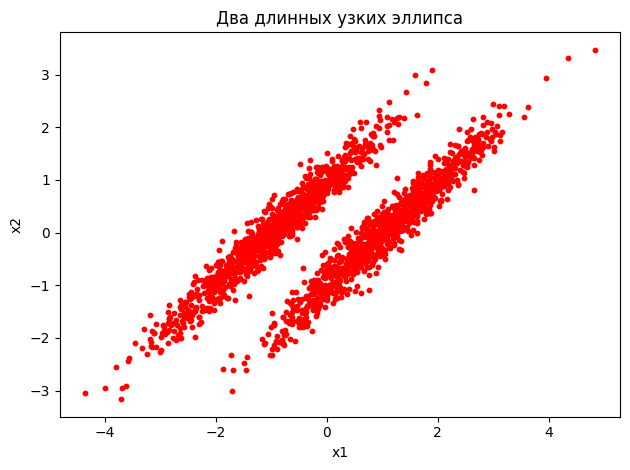

In [491]:
N = 1000

# угол
angle = np.deg2rad(45)

# дисперсии вдоль главных осей эллипса:
d1 = 2.0
d2 = 0.03

# построим матрицу перехода при вращении
rotate = np.array([[ np.cos(angle), -np.sin(angle)],
              [ np.sin(angle),  np.cos(angle) ]])

# cov в базовых координатах:
cov = np.diag([d1, d2])

# cov с учётом поворота эллипса в новых координатах:
cov_rotated = rotate @ cov @ rotate.T

# центры двух эллипсов
mean1 = np.array([-1.0, 0.0])
mean2 = np.array([ 1.0, 0.0])

s1 = np.random.multivariate_normal(mean1, cov_rotated, size=N)
s2 = np.random.multivariate_normal(mean2, cov_rotated, size=N)

# Склеим s1 и s2
s = np.vstack([s1, s2])

# print(s1.shape)
# print(s2.shape)

# print(S.shape)

plt.scatter(s[:,0], s[:,1], color='r', s=10)

plt.title('Два длинных узких эллипса')
plt.xlabel('x1')
plt.ylabel('x2')

plt.tight_layout()
plt.show()


**5. [0.1 балла]** Сделайте SVD и нарисуйте направления новых признаков.

/var/folders/l4/2y8c0j1d7c7g1xtmkvv06f4c0000gn/T/ipykernel_77901/3146852920.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X[:,0], y=X[:,1], shade=False, color='g', alpha=0.7)


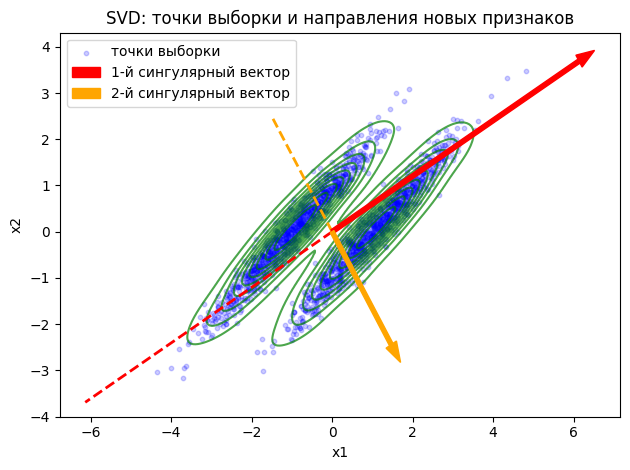

In [492]:
do_svd_and_draw_dots_with_directions(s)

Если бы мы решали задачу анализа данных, то скорее всего нас интересовал признак, который бы разделял два кластера (в данном случае два эллипса), то есть такая функция $f(x)$, для которой
$$f(x) < c,\ \text{если объект $x$ из первого класса}$$
$$f(x) > c,\ \text{если объект $x$ из второго класса}$$
для некоторого числа $c$.

**6. [0.25 балла]** Помогает ли какой-нибудь из двух предоставленных SVD признаков обнаружить эту структуру? Обязательно поясните свой ответ.

Мы знаем, что благодаря SVD нашли 2 сингулярных вектора, вдоль первого дисперсия максимальна, вдоль второго минимальна, тогда если у нас 2 вытянутых узких эллипса, то максимальная дисперсия будет проходить "почти" между ними, то есть первый сингулярный вектор как раз будет разделять наши кластеры.(Ну или почти разделять), что мы и видим на графике.

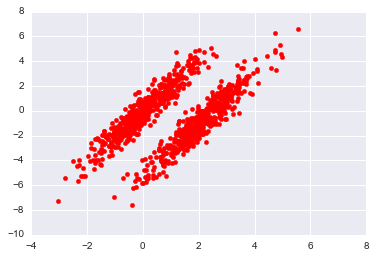

In [ ]:
# Just keep this image as a sample

**7. [0 баллов]** Сгенерируйте выборку из 1000 точек $x_1,\ldots,x_{1000}$ из нормального распределения с вектором средних $a = (1,1)$ и ковариационной матрицей

$$\Sigma = \begin{pmatrix}
1 & 0\\
0 & 4
\end{pmatrix}.$$

In [493]:
N = 1000
s = np.random.multivariate_normal(mean=np.array([1,1]), cov=np.array([[1,0],[0,20]]), size=N)

**8. [0.2 балла]** Очевидно, что "интересными" для этого датасета направлениями будут направления полуосей эллипса-облака точек. Глядя только на матрицу $\Sigma$, определите, что это будут за направления? Поясните свой ответ.

Матрица ковариации уже диагональна, тогда получим, что оси независимы, а значит направления будут:

$$
v_1 = (1, 0) \\
v_2 = (0, 1)
$$

При этом если умножать на сингулярное значение, то получим $v_2$ будет больше $v_1$, то есть вдоль оси $y$ элдипсоид будет более вытянут.

(На графике этого не видно, так как у него еденичные отрезки на осях разные, а не одинаковые, но по еденичным отрезкам как раз это хорошо видно).

**9. [0.1 балла]** Сделайте SVD-разложение $X = U\Sigma V^T$. Нарисуйте все точки $x_i$ на плоскости и направления новых признаков.

/var/folders/l4/2y8c0j1d7c7g1xtmkvv06f4c0000gn/T/ipykernel_77901/3146852920.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X[:,0], y=X[:,1], shade=False, color='g', alpha=0.7)


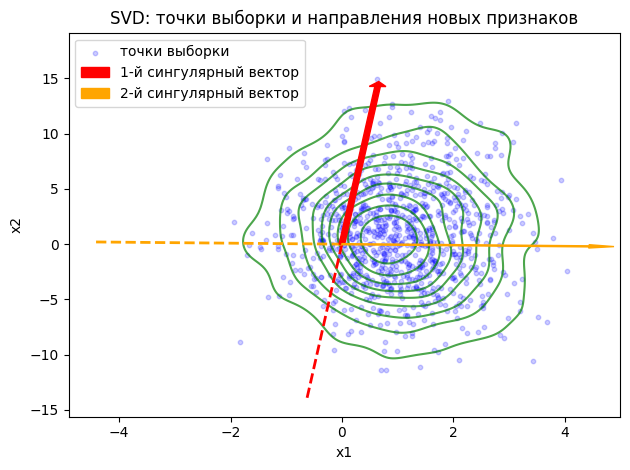

In [494]:
do_svd_and_draw_dots_with_directions(s)

**10. [0.4 балла]** Сделайте вывод: в чём проблема и как можно её исправить?

Видим, что пошло что-то не так, во первых вектора направления идут неправильно(особенно первый) и начало векторов из (0, 0), а не из центра эллипса. 
Вероятно все происходит из-за сдвига(центр эллипса находится в точке $a = (1, 1)$), а до этого такой проблемы не было так как везде был $a = (0, 0)$.

Чтобы это исправить можно из каждого признака отнять 1(то есть из первой и второй координаты), но заметим, что мы по сути занимаемся усреднением данных(как делали выше), то есть из каждого признака отмнимаем его среднее.

Давайте допольнительно проверю нашу теорию на практике.

[1.00365754 0.91161364]


/var/folders/l4/2y8c0j1d7c7g1xtmkvv06f4c0000gn/T/ipykernel_77901/3146852920.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(x=X[:,0], y=X[:,1], shade=False, color='g', alpha=0.7)


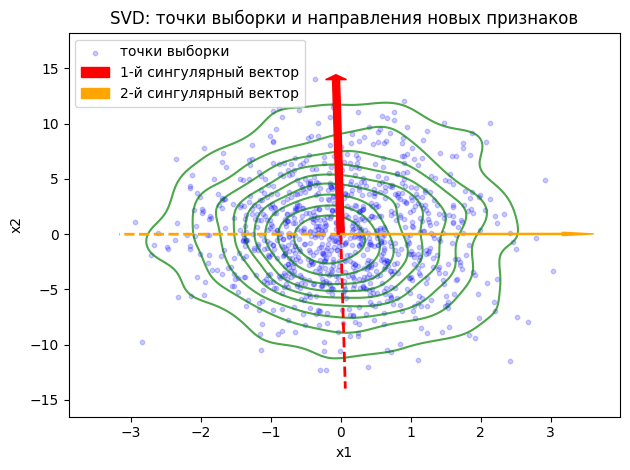

In [495]:
sc = s - s.mean(axis=0)
print(s.mean(axis=0))
do_svd_and_draw_dots_with_directions(sc)